In [2]:
import numpy as np
from src.monte_carlo import monte_carlo_call_price
S_0=100       # current stock price
r=0.05       # risk-free interest rate
sigma=0.20   # volatility
T=1          # time to maturity (years)
K=100        # strike price

In [3]:
n_runs=100
results = []
for N in [100,1000,10000,100000]:
    prices = []
    for i in range(n_runs):
        prices.append(monte_carlo_call_price(S_0,r,sigma,T,K,N))
    print(N,np.mean(prices),np.std(prices))
    results.append({
        "N": N,
        "mean_price": np.mean(prices),
        "std_price": np.std(prices)
    })

#generates mean and standard deviation of stock prices for different number of simulations

100 10.535597074402247 1.565380845489372
1000 10.474919191841046 0.4657597376514605
10000 10.466668868155086 0.1541943436875986
100000 10.45875023176332 0.041614541505339754


In [4]:
import pandas as pd
df = pd.DataFrame(results)
df

#table of results above

,N,mean_price,std_price
0,100,10.535597,1.565381
1,1000,10.474919,0.465760
2,10000,10.466669,0.154194
3,100000,10.458750,0.041615


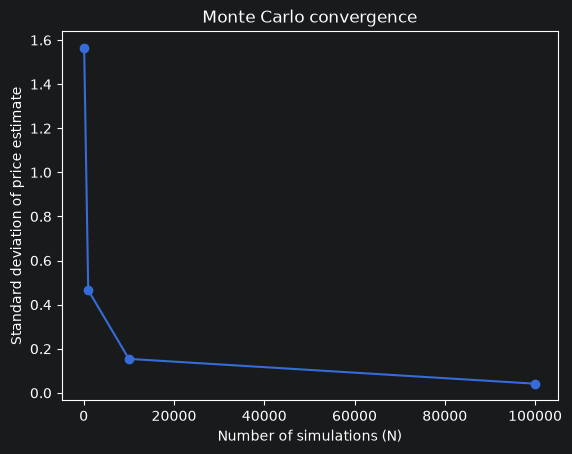

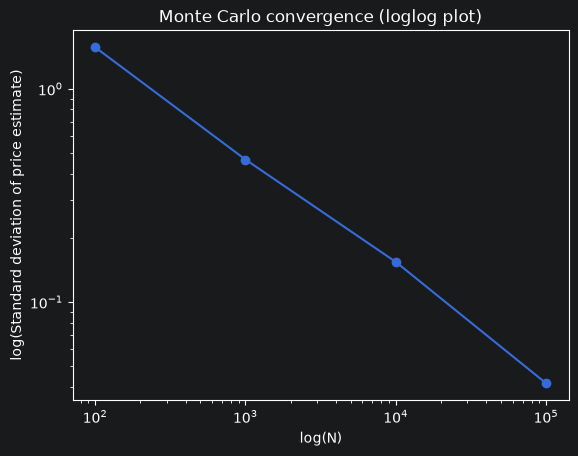

In [5]:
import matplotlib.pyplot as plt
plt.plot(df["N"], df["std_price"], marker="o")
plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation of price estimate")
plt.title("Monte Carlo convergence")
plt.show()
plt.loglog(df["N"], df["std_price"], marker="o")
plt.xlabel("log(N)")
plt.ylabel("log(Standard deviation of price estimate)")
plt.title("Monte Carlo convergence (loglog plot)")
plt.show()

#normal and log log plots of results above

In [6]:
x = np.log(df["N"])
y = np.log(df["std_price"])

slope, intercept = np.polyfit(x, y, 1)
print("Estimated convergence rate:", slope)

#gradient of log log plot is the estimated convergence rate; should be -0.5

Estimated convergence rate: -0.5206218204467296


In [10]:
from src.black_scholes import call_price

bs_price = float(call_price(S_0,r,sigma,T,K))
print("Black-Scholes price:", bs_price)

#analytical Black-Scholes call price

Black-Scholes price: 10.450583572185565


In [11]:
df["error"] = abs(df["mean_price"] - bs_price)
df["percentage_error"] = df["error"] / bs_price * 100
df

#columns added to table showing error between monte-carlo methods and theoretical

,N,mean_price,std_price,error,percentage_error
0,100,10.535597,1.565381,0.085014,0.813481
1,1000,10.474919,0.465760,0.024336,0.232864
2,10000,10.466669,0.154194,0.016085,0.153918
3,100000,10.458750,0.041615,0.008167,0.078145


In [12]:
results_ci = []
for N in [100,1000,10000,100000]:
    Z=np.random.normal(0,1,N)
    ST=S_0*np.exp((r-(sigma**2)/2)*T+sigma*np.sqrt(T)*Z)
    payoff=np.maximum(0,ST-K)
    payoff_mean=np.mean(payoff)
    payoff_std=np.std(payoff,ddof=1)
    prices=payoff_mean*np.exp(-r*T)
    standard_error = np.exp(-r * T) * payoff_std / np.sqrt(N)
    lower = prices - 1.96 * standard_error
    upper = prices + 1.96 * standard_error
    print(N,prices,standard_error,lower,upper)
    results_ci.append({
        "N": N,
        "monte_carlo_price": prices,
        "standard_error": standard_error,
        "lower_confidence_interval": lower,
        "upper_confidence_interval": upper
    })

#as number of simulations increase, standard deviation is smaller and the bounds close in towards the theoretical value

100 9.67431016773027 1.3585057736511963 7.011638851373926 12.336981484086616
1000 10.995074537737707 0.47767858997215784 10.058824501392278 11.931324574083137
10000 10.37434348856864 0.1450941942720549 10.089958867795412 10.658728109341867
100000 10.49247313728914 0.046585153890903834 10.401166235662968 10.583780038915313


In [13]:
df_ci = pd.DataFrame(results_ci)
df_ci

#table of results above

,N,monte_carlo_price,standard_error,lower_confidence_interval,upper_confidence_interval
0,100,9.674310,1.358506,7.011639,12.336981
1,1000,10.995075,0.477679,10.058825,11.931325
2,10000,10.374343,0.145094,10.089959,10.658728
3,100000,10.492473,0.046585,10.401166,10.583780


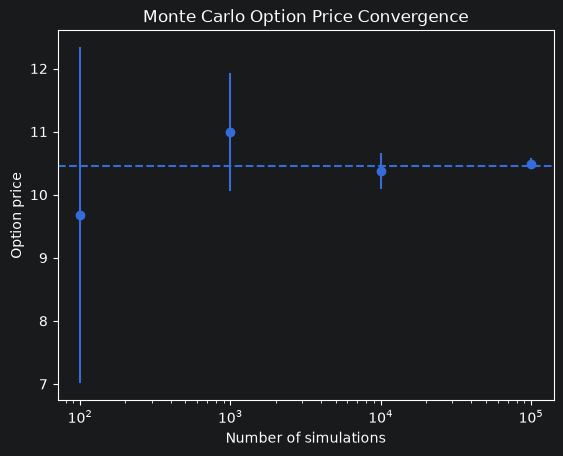

In [14]:
plt.errorbar(
    df_ci["N"],
    df_ci["monte_carlo_price"],
    yerr=1.96 * df_ci["standard_error"],
    fmt="o"
)

plt.axhline(bs_price, linestyle="--")

plt.xscale("log")
plt.xlabel("Number of simulations")
plt.ylabel("Option price")
plt.title("Monte Carlo Option Price Convergence")
plt.show()

#plot of results above, with error bars

In [16]:
from src.antithetic import antithetic_call_price

price = antithetic_call_price(S_0,r,sigma,T,K,10000)
print(price)

#antithetic price

10.370251736422835


In [17]:
n_runs = 100
N = 10000

standard_prices = []
antithetic_prices = []
for i in range(n_runs):
    # Standard Monte Carlo
    standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

    # Antithetic Monte Carlo
    antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))

print("Standard MC:")
print("Mean:", np.mean(standard_prices))
print("Std:", np.std(standard_prices))
print()
print("Antithetic MC:")
print("Mean:", np.mean(antithetic_prices))
print("Std:", np.std(antithetic_prices))

#mean and standard deviations of standard and antithetic prices; the standard deviation for standard is larger than antithetic

Standard MC:
Mean: 10.47151522886029
Std: 0.13603608831639896

Antithetic MC:
Mean: 10.453255275859272
Std: 0.06939982306055277


In [18]:
simulation_sizes = [100, 1000, 10000, 100000]
n_runs = 100
comparison_results = []

for N in simulation_sizes:
    standard_prices = []
    antithetic_prices = []
    for i in range(n_runs):
        # Standard Monte Carlo
        standard_prices.append(monte_carlo_call_price(S_0, r, sigma, T, K, N))

        # Antithetic Monte Carlo
        antithetic_prices.append(antithetic_call_price(S_0,r,sigma,T,K,N))
    comparison_results.append({
        "N": N,
        "standard_mean": np.mean(standard_prices),
        "standard_std": np.std(standard_prices),
        "antithetic_mean": np.mean(antithetic_prices),
        "antithetic_std": np.std(antithetic_prices)
    })

#varying number of simulations to acquire mean and std of standard and antithetic

In [19]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df

#table of results above

,N,standard_mean,standard_std,antithetic_mean,antithetic_std
0,100,10.385578,1.384178,10.542014,0.606161
1,1000,10.487965,0.477812,10.415979,0.248592
2,10000,10.465766,0.155613,10.456807,0.082428
3,100000,10.454715,0.047486,10.451396,0.023972


In [20]:
comparison_df["variance_reduction"] = (1 -(comparison_df["antithetic_std"] ** 2)
    / (comparison_df["standard_std"] ** 2)) * 100

comparison_df

#added percentage reduction of variance to table

,N,standard_mean,standard_std,antithetic_mean,antithetic_std,variance_reduction
0,100,10.385578,1.384178,10.542014,0.606161,80.822491
1,1000,10.487965,0.477812,10.415979,0.248592,72.931860
2,10000,10.465766,0.155613,10.456807,0.082428,71.941753
3,100000,10.454715,0.047486,10.451396,0.023972,74.514816


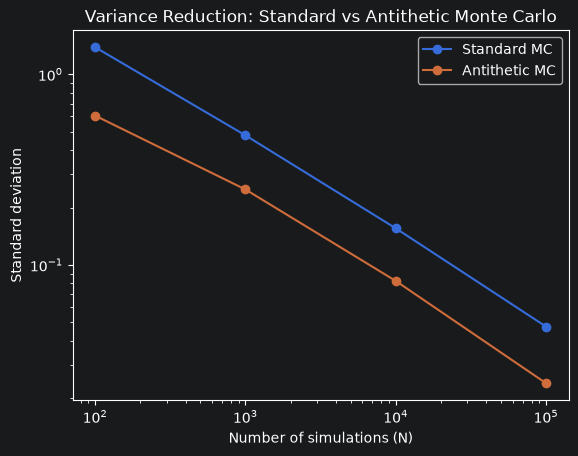

In [21]:
plt.loglog(
    comparison_df["N"],
    comparison_df["standard_std"],
    marker="o",
    label="Standard MC"
)

plt.loglog(
    comparison_df["N"],
    comparison_df["antithetic_std"],
    marker="o",
    label="Antithetic MC"
)

plt.xlabel("Number of simulations (N)")
plt.ylabel("Standard deviation")
plt.title("Variance Reduction: Standard vs Antithetic Monte Carlo")
plt.legend()
plt.show()

#log log plots of both standard and antithetic std

In [22]:
standard_se = comparison_df.loc[
    comparison_df["N"] == 100000, "standard_std"
].iloc[0]

antithetic_se = comparison_df.loc[
    comparison_df["N"] == 100000, "antithetic_std"
].iloc[0]

efficiency = (standard_se / antithetic_se) ** 2

print("Efficiency improvement:", efficiency)
print("Equivalent standard MC simulations:", 100000 * efficiency)

#efficiency calculation: how many more times of simulations standard need to keep up with antithetic

Efficiency improvement: 3.923848484741368
Equivalent standard MC simulations: 392384.8484741368


In [24]:
from src.black_scholes import call_delta

bs_delta = call_delta(S_0,r, sigma, T,K)
print("Black-Scholes Delta:", bs_delta)

#theoretical Black-scholes delta

Black-Scholes Delta: 0.6368306511756191
